# ForceSMIP Challenge Analysis - Tier 1

This notebook demonstrates the ForceSMIP analysis on Tier 1

## 1. Setup and Imports

In [1]:
import sys
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

# Add src to path
sys.path.append(os.path.join(os.getcwd(), "ForceSMIP"))


# Use package imports instead:
from ForceSMIP.data_loader import ForceSMIPDataLoader
from ForceSMIP.preprocessing import yearly_average, compute_yearly_average_dict, merge_training_data, reshape_training_data, apply_notnan_filter_complete, capture_nans, moving_average_smoothing
from ForceSMIP.algorithms import ridge_regression, LowRankSolver
from ForceSMIP.evaluation import ForceSMIPEvaluator, compute_trends_from_data
from ForceSMIP.visualization import ForceSMIPVisualizer

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("Modules loaded successfully!")


Modules loaded successfully!


## 2.  Data path where there is forceSMIP data folder. 

In [2]:
# Initialize pipeline
base_path = '/net/krypton/climdyn_nobackup/FTP'

# variable names: pr, prmax, psl, tas, tos, tasmax, tasmin, zmta
variable = 'psl'  # Pressure at Sea Level

## 3. Step-by-Step Analysis (Manual Pipeline)

### 3.1 Data Loading

#### Training data loading

In [3]:
# Initialize data loader
data_loader = ForceSMIPDataLoader(base_path)

# Load training data
print("Loading training data...")
dic_data, dic_forced_response, longitude, latitude = data_loader.load_training_data(variable)

print(f"Training data loaded:")
print(f"  Number of models: {len(dic_data)}")
print(f"  Model names: {list(dic_data.keys())}")
print(f"  Grid shape: {latitude.shape[0]} x {longitude.shape[0]}")
print(f"  Time steps: {list(dic_data.values())[0].shape[1]}")

Loading training data...
Processing 1/5: CESM2
  Processing 1/50: psl_mon_CESM2_historical_ssp370_r1251.013i1p1f1.188001-210012.nc
  Processing 2/50: psl_mon_CESM2_historical_ssp370_r1011.001i1p1f1.188001-210012.nc
  Processing 3/50: psl_mon_CESM2_historical_ssp370_r1251.015i1p1f1.188001-210012.nc
  Processing 4/50: psl_mon_CESM2_historical_ssp370_r1031.002i1p1f1.188001-210012.nc
  Processing 5/50: psl_mon_CESM2_historical_ssp370_r1251.014i1p1f1.188001-210012.nc
  Processing 6/50: psl_mon_CESM2_historical_ssp370_r1051.003i1p1f1.188001-210012.nc
  Processing 7/50: psl_mon_CESM2_historical_ssp370_r1251.016i1p1f1.188001-210012.nc
  Processing 8/50: psl_mon_CESM2_historical_ssp370_r1071.004i1p1f1.188001-210012.nc
  Processing 9/50: psl_mon_CESM2_historical_ssp370_r1251.017i1p1f1.188001-210012.nc
  Processing 10/50: psl_mon_CESM2_historical_ssp370_r1091.005i1p1f1.188001-210012.nc
  Processing 11/50: psl_mon_CESM2_historical_ssp370_r1251.018i1p1f1.188001-210012.nc
  Processing 12/50: psl_mon

#### Test data loading

In [4]:
# Load test data
test_models = ['1A','1B','1C','1D','1E','1F','1G','1J']
print("\nLoading test data...")
data_test, temporal_means = data_loader.load_test_data(variable, tier= 'Tier1',test_models=test_models)
data_ground_truth = data_loader.load_ground_truth(variable,test_models=test_models)
data_estimates = data_loader.load_estimates(variable, test_models=test_models)


print(f"Test data shape: {data_test.shape}")
print(f"Ground truth shape: {data_ground_truth.shape}")
print(f"Estimates shape: {data_estimates.shape}")


Loading test data...
Files in test data directory: ['psl_mon_1A.195001-202212.nc', 'psl_mon_1B.195001-202212.nc', 'psl_mon_1C.195001-202212.nc', 'psl_mon_1D.195001-202212.nc', 'psl_mon_1E.195001-202212.nc', 'psl_mon_1F.195001-202212.nc', 'psl_mon_1G.195001-202212.nc', 'psl_mon_1H.195001-202212.nc', 'psl_mon_1I.195001-202212.nc', 'psl_mon_1J.195001-202212.nc']
Loading test data for 1A at index 0
create data_test array
Monthly centering
Loading test data for 1B at index 1
Monthly centering
Loading test data for 1C at index 2
Monthly centering
Loading test data for 1D at index 3
Monthly centering
Loading test data for 1E at index 4
Monthly centering
Loading test data for 1F at index 5
Monthly centering
Loading test data for 1G at index 6
Monthly centering
Loading test data for 1J at index 7
Monthly centering
Loading ground truth for 1A at index 0
Loading ground truth for 1B at index 1
Loading ground truth for 1C at index 2
Loading ground truth for 1D at index 3
Loading ground truth for 1

### 3.2 Data Preprocessing

#### Aggregate data and compute yearly means

In [5]:
# Compute yearly averages
print("Computing yearly averages...")
dic_data_yearly = compute_yearly_average_dict(dic_data)
dic_forced_response_yearly = compute_yearly_average_dict(dic_forced_response)

data_test_yearly = yearly_average(data_test)
data_ground_truth_yearly = yearly_average(data_ground_truth)

print(f"Yearly data shape (first model): {list(dic_data_yearly.values())[0].shape}")
print(f"Test yearly shape: {data_test_yearly.shape}")

Computing yearly averages...
Yearly data shape (first model): (50, 221, 72, 144)
Test yearly shape: (8, 73, 72, 144)


#### Merge training data into X,Y data matrices: 
#### X (nb of runs * time length, longitude * latitude)
#### Y (nb of runs * time length, longitude * latitude)

In [6]:
# Prepare training data for machine learning
print("Preparing training data...")

# Method 1: Merge all training data
x_train_merged, y_train_merged = merge_training_data(
    dic_data_yearly, dic_forced_response_yearly
)

# Method 2: Keep model separation
x_train_dict, y_train_dict = reshape_training_data(
    dic_data_yearly, dic_forced_response_yearly
)

print(f"Merged training data shape: X={x_train_merged.shape}, Y={y_train_merged.shape}")
print(f"Separated training data: {len(x_train_dict)} models")

Preparing training data...
Merged training data shape: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])
Separated training data: 5 models


### 3.3 Filter the data 
#### remove the NaNs from the training set 
#### replace the NaNs in the test set by 0s

In [7]:
nan_idx, notnan_idx =capture_nans(x_train_dict)

# Prepare test data for smoothing experiments
x_test = torch.from_numpy(data_test.reshape(
    data_test.shape[0], data_test.shape[1], -1
)).to(torch.float32)

print(f"Test data shape for smoothing: {x_test.shape}")

Test data shape for smoothing: torch.Size([8, 876, 10368])


In [8]:
# add the nans that are also included in the test data
# record nan indices as the union of nans on each map
nan_idx_test = nan_idx.copy()

for idx_r in range(x_test.shape[0]):

    # get nan mask of test set 
    # nan_mask = np.where(np.abs(x_test[idx_r,:,:])>1e9, True, False)
    nan_mask = np.where(np.isnan(x_test[idx_r,:,:])==True, True, False)

    # get the index of columns where there is at least one True in the nan mask
    col_indices = np.where(np.any(nan_mask, axis=0))[0]

    nan_idx_test = list(set(nan_idx_test) | set(col_indices))    

# define not nan indices (useful to ease the computations)
notnan_idx_test = list(set(list(range(x_test.shape[2]))) - set(nan_idx_test))

# replace the nan index by Nans
notnan_idx = notnan_idx_test
nan_idx = nan_idx_test

/tmp/ipykernel_39410/3558715273.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  nan_mask = np.where(np.isnan(x_test[idx_r,:,:])==True, True, False)


In [9]:
# Apply not-NaN filter to all data
x_train_merged_filtered, y_train_merged_filtered, \
x_train_dict_filtered, y_train_dict_filtered, x_test_filtered = apply_notnan_filter_complete(
    x_train_merged, y_train_merged,
    x_train_dict, y_train_dict,
    x_test, notnan_idx
)

              APPLYING NOT-NAN FILTER TO ALL DATA
Valid indices count: 10368

1. Filtering merged training data...
   X: torch.Size([40885, 10368]) -> torch.Size([40885, 10368])
   Y: torch.Size([40885, 10368]) -> torch.Size([40885, 10368])

2. Filtering training dictionaries...
Filtering training dictionaries...
Keeping 10368 valid spatial features
torch.Size([50, 221, 10368])
CESM2: X torch.Size([50, 221, 10368]) -> torch.Size([50, 221, 10368])
torch.Size([25, 221, 10368])
CanESM5: X torch.Size([25, 221, 10368]) -> torch.Size([25, 221, 10368])
torch.Size([30, 221, 10368])
MIROC-ES2L: X torch.Size([30, 221, 10368]) -> torch.Size([30, 221, 10368])
torch.Size([50, 221, 10368])
MIROC6: X torch.Size([50, 221, 10368]) -> torch.Size([50, 221, 10368])
torch.Size([30, 221, 10368])
MPI-ESM1-2-LR: X torch.Size([30, 221, 10368]) -> torch.Size([30, 221, 10368])

3. Filtering test data...
   Test: torch.Size([8, 876, 10368]) -> torch.Size([8, 876, 10368])

=== FILTERING SUMMARY ===
Original spatia

### 3.4 Model Training

In [24]:
# Updated cell for model training
# Train global ridge regression model (arbitrary choice of lambda)
lambda_reg = 100000.0
# print(f"Training ridge regression with lambda={lambda_reg}...")

w_ridge = ridge_regression(x_train_merged_filtered,y_train_merged_filtered, lambda_reg, surface=None, verbose=True)
print(f"Ridge weights shape: {w_ridge.shape}")

Solving ridge regression with λ=100000.0
Input shape: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])
Reshaped: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])


Ridge weights computed: torch.Size([10368, 10368])
Ridge weights shape: torch.Size([10368, 10368])


In [25]:
# Setup low-rank solver for efficient multiple rank solutions
print(f"\nSetting up low-rank solver...")
lr_solver = LowRankSolver()
lr_solver.W_full = w_ridge
lr_solver.fit(x_train_merged_filtered, y_train_merged_filtered, lambda_reg,surface=None, verbose=True)

# Get solutions for multiple ranks efficiently
ranks_to_test = [2, 5, 10, 15, 20, 25, 30]
rank_solutions = lr_solver.get_multiple_ranks(ranks_to_test, verbose=True)

# Print explained variance for different ranks
print(f"\nExplained variance by rank:")
cumulative_var = lr_solver.cumulative_variance_ratio()
for rank in ranks_to_test:
    if rank <= len(cumulative_var):
        print(f"  Rank {rank}: {cumulative_var[rank-1]:.4f}")

# Use the primary rank solution
primary_rank = 10
w_ridge_lr = rank_solutions[primary_rank]
print(f"Primary rank-{primary_rank} weights shape: {w_ridge_lr.shape}")


Setting up low-rank solver...
Computing SVD for low-rank approximations...


SVD computed: U=torch.Size([51253, 10368]), S=torch.Size([10368]), Vt=torch.Size([10368, 10368])
Singular values range: 0.000570 to 294363.250000
Computed solutions for ranks: [2, 5, 10, 15, 20, 25, 30]

Explained variance by rank:
  Rank 2: 0.9414
  Rank 5: 0.9881
  Rank 10: 0.9972
  Rank 15: 0.9984
  Rank 20: 0.9989
  Rank 25: 0.9992
  Rank 30: 0.9994
Primary rank-10 weights shape: torch.Size([10368, 10368])


### Make predictions

In [26]:
# Make predictions using different methods
print("Making predictions...")

# compute smoothed test data
x_test_smooth = moving_average_smoothing(x_test_filtered, window_size=12*10, mode='same')

# Global models
y_pred_ridge = x_test_filtered @ w_ridge
y_pred_ridge_lr = x_test_filtered @ w_ridge_lr

y_pred_ridge_smooth = x_test_smooth @ w_ridge
y_pred_ridge_lr_smooth = x_test_smooth @ w_ridge_lr

Making predictions...


### 3.7 Evaluate the methods on test set 

In [27]:
# Initialize evaluator
evaluator = ForceSMIPEvaluator()

# Convert predictions to yearly averages and compute trends
def to_yearly_and_trends(pred_data, trend_years=slice(30, None)):
    """Helper function to convert monthly to yearly and compute trends."""
    pred_numpy = pred_data.cpu().numpy() if isinstance(pred_data, torch.Tensor) else pred_data
    pred_yearly = pred_numpy.reshape(pred_numpy.shape[0], pred_numpy.shape[1] // 12, 12, pred_numpy.shape[2])
    pred_yearly = np.nanmean(pred_yearly, axis=2)
    return compute_trends_from_data(pred_yearly, trend_years)

# Compute trends for all predictions
trend_years = slice(30, None)  # Last 43 years for trend computation

# reshape the data ground truth for trend computation
data_ground_truth_yearly = data_ground_truth_yearly.reshape(
    data_ground_truth_yearly.shape[0], 
    data_ground_truth_yearly.shape[1],
    -1
)

trends_ground_truth = compute_trends_from_data(data_ground_truth_yearly, trend_years)
trends_ridge = to_yearly_and_trends(y_pred_ridge, trend_years)
trends_ridge_smooth = to_yearly_and_trends(y_pred_ridge_smooth, trend_years)
trends_ridge_lr = to_yearly_and_trends(y_pred_ridge_lr, trend_years)
trends_ridge_lr_smooth = to_yearly_and_trends(y_pred_ridge_lr_smooth, trend_years)


print(f"Trends computed for {trends_ground_truth.shape[0]} test cases")
print(f"Trend groundtruth shape: {trends_ground_truth.shape}")
print(f"Trend shape: {trends_ridge.shape}")

Trends computed for 8 test cases
Trend groundtruth shape: (8, 10368)
Trend shape: (8, 10368)


In [28]:
# Evaluate all methods
predictions_dict = {
    'Ridge': trends_ridge,
    'Ridge + Low-rank': trends_ridge_lr,
    'Ridge + Smoothing': trends_ridge_smooth,
    'Ridge + Low-rank + Smoothing': trends_ridge_lr_smooth
}

comparison_results = evaluator.compare_methods(predictions_dict, trends_ground_truth[:, notnan_idx])

print("\n=== Method Comparison ===")
for method, results in comparison_results.items():
    print(f"\n{method}:")
    print(f"  Mean NRMSE: {results['mean_nrmse']:.4f}")
    print(f"  Mean Pattern Corr: {results['mean_pattern_corr']:.4f}")
    print(f"  Worst NRMSE: {results['worst_nrmse']:.4f}")
    print(f"  NRMSE Variance: {results['variance_nrmse']:.4f}")


=== Method Comparison ===

Ridge:
  Mean NRMSE: 0.4848
  Mean Pattern Corr: 0.9084
  Worst NRMSE: 0.7919
  NRMSE Variance: 0.0419

Ridge + Low-rank:
  Mean NRMSE: 0.4921
  Mean Pattern Corr: 0.9071
  Worst NRMSE: 0.7769
  NRMSE Variance: 0.0373

Ridge + Smoothing:
  Mean NRMSE: 0.4969
  Mean Pattern Corr: 0.9036
  Worst NRMSE: 0.8126
  NRMSE Variance: 0.0465

Ridge + Low-rank + Smoothing:
  Mean NRMSE: 0.5042
  Mean Pattern Corr: 0.9018
  Worst NRMSE: 0.7986
  NRMSE Variance: 0.0418


## 4. Visualization

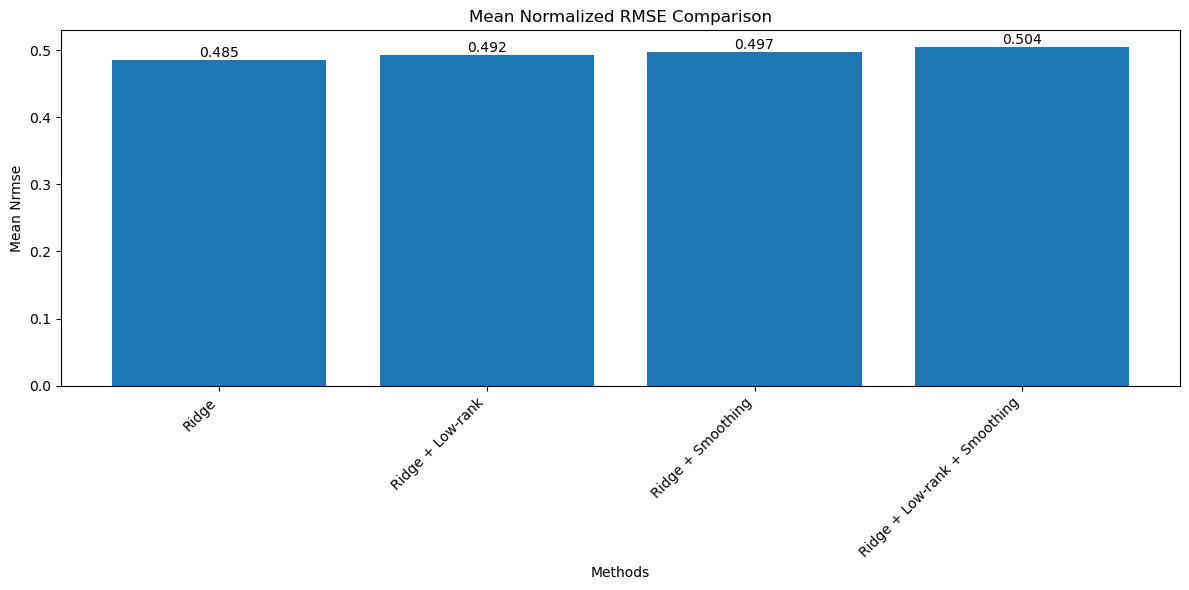

In [29]:
# Initialize visualizer
visualizer = ForceSMIPVisualizer(longitude, latitude, test_models)

# Plot performance comparison
fig = evaluator.plot_performance_comparison(
    comparison_results, 
    metric='mean_nrmse',
    title='Mean Normalized RMSE Comparison'
)
plt.show()

In [30]:
# reshape the trends for visualization
trends_ridge_fullmap = np.zeros((trends_ridge.shape[0], x_test.shape[2]), dtype=np.float32)
trends_ridge_fullmap[:,notnan_idx] = trends_ridge
trends_ridge_fullmap[:,nan_idx] = np.nan  # Fill NaNs for visualization

trends_ridge_lr_fullmap = np.zeros((trends_ridge_lr.shape[0], x_test.shape[2]), dtype=np.float32)
trends_ridge_lr_fullmap[:,notnan_idx] = trends_ridge_lr
trends_ridge_lr_fullmap[:,nan_idx] = np.nan  # Fill NaNs


trends_ground_truth_fullmap =np.zeros((trends_ridge.shape[0], x_test.shape[2]), dtype=np.float32)
trends_ground_truth_fullmap[:,notnan_idx] = trends_ground_truth[:,notnan_idx]
trends_ground_truth_fullmap[:,nan_idx] = np.nan  # Fill NaNs for visualization


trend_test_member = compute_trends_from_data(data_test_yearly.reshape(
    data_test_yearly.shape[0],
    data_test_yearly.shape[1],
    -1
), trend_years)

### Display the trend maps

Using vmin=-0.05, vmax=0.05 for colorbar
Using vmin=-0.05, vmax=0.05 for colorbar
Using vmin=-0.05, vmax=0.05 for colorbar
Using vmin=-0.05, vmax=0.05 for colorbar


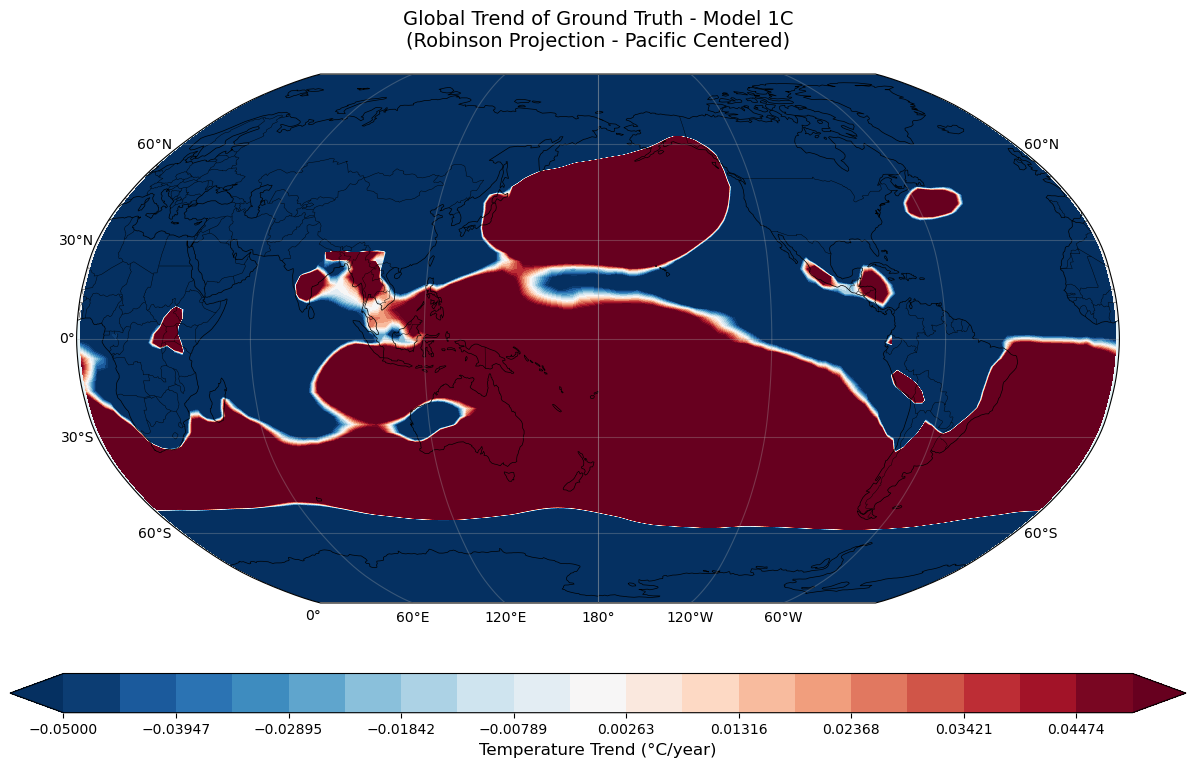

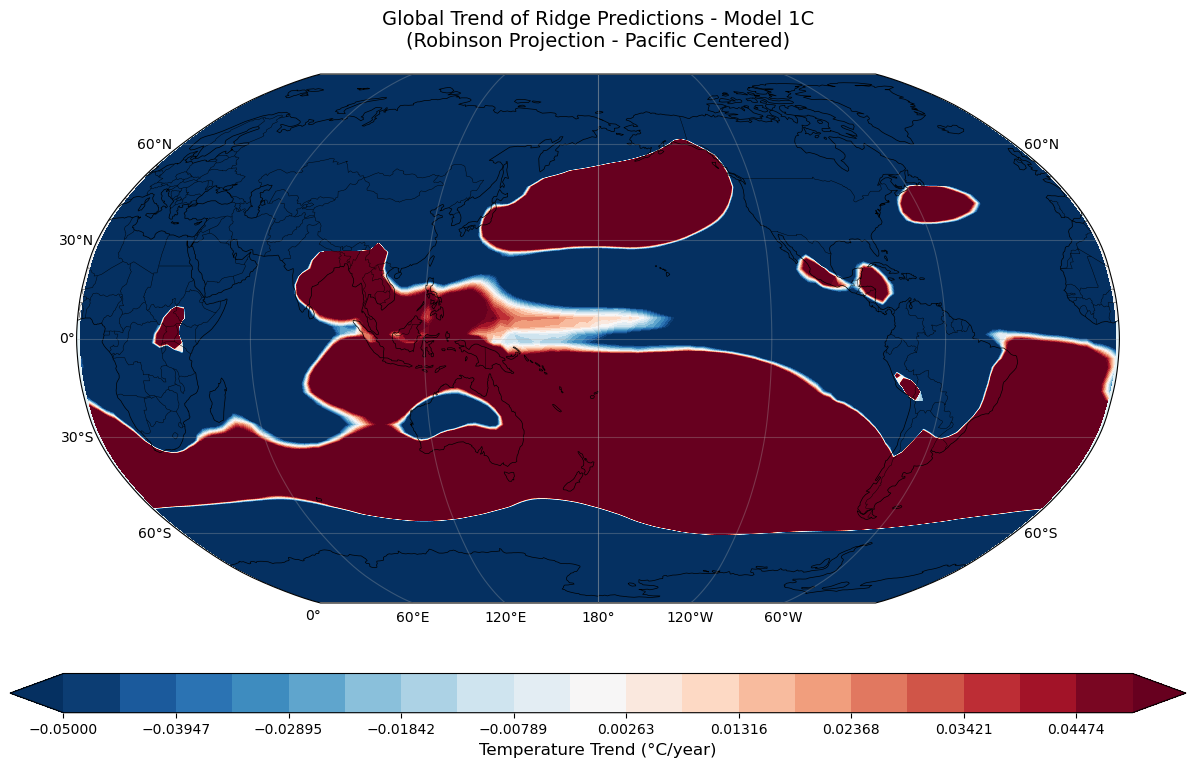

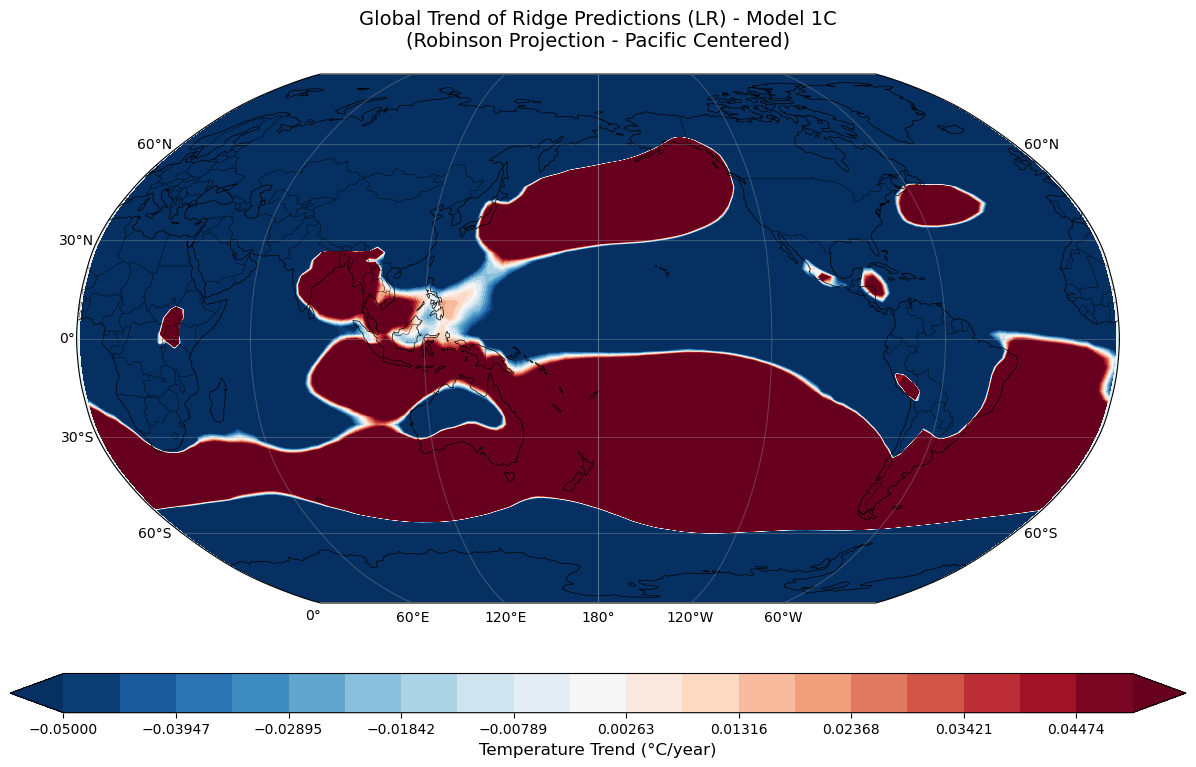

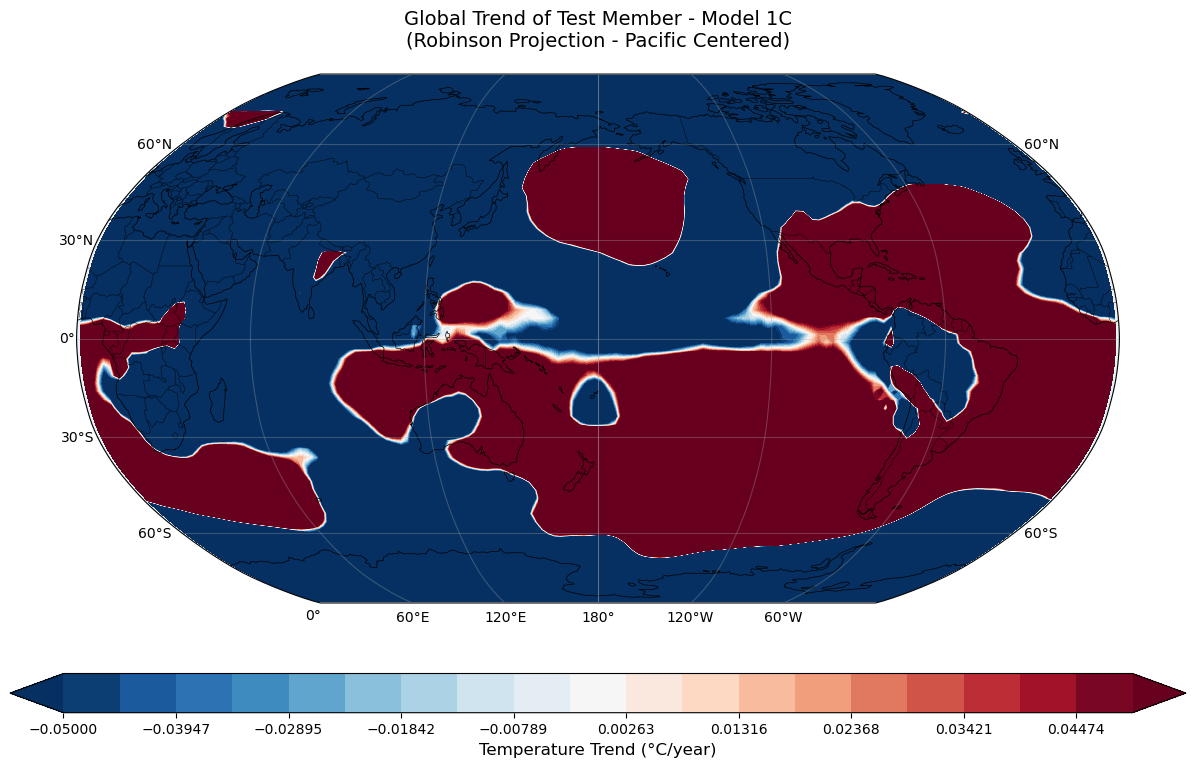

In [31]:
run_idx = 2 # First test model

fig = visualizer.plot_robinson_projection(trends_ground_truth_fullmap, 
                                title="Global Trend of Ground Truth",
                                cmap='RdBu_r', 
                                run_idx=run_idx,
                                vmin=-0.05, vmax=0.05,
                                central_longitude = 180)
plt.savefig('figures/trend_map_gt_{}_{}.png'.format(variable,run_idx), dpi=300)

fig = visualizer.plot_robinson_projection(trends_ridge_fullmap, 
                                title="Global Trend of Ridge Predictions",
                                cmap='RdBu_r', 
                                run_idx= run_idx, 
                                vmin=-0.05, vmax=0.05,
                                central_longitude = 180)
plt.savefig('figures/trend_map_ridge_{}_{}.png'.format(variable, run_idx), dpi=300)

fig = visualizer.plot_robinson_projection(trends_ridge_lr_fullmap, 
                                title="Global Trend of Ridge Predictions (LR)",
                                cmap='RdBu_r', 
                                run_idx=run_idx, 
                                vmin=-0.05, vmax=0.05,
                                central_longitude = 180)
plt.savefig('figures/trend_map_ridge_lr_{}_{}.png'.format(variable, run_idx), dpi=300)

fig = visualizer.plot_robinson_projection(trend_test_member, 
                                title="Global Trend of Test Member",
                                cmap='RdBu_r', 
                                run_idx=run_idx, 
                                vmin=-0.05, vmax=0.05,
                                central_longitude = 180)
plt.savefig('figures/trend_map_test_member_{}_{}.png'.format(variable, run_idx), dpi=300)

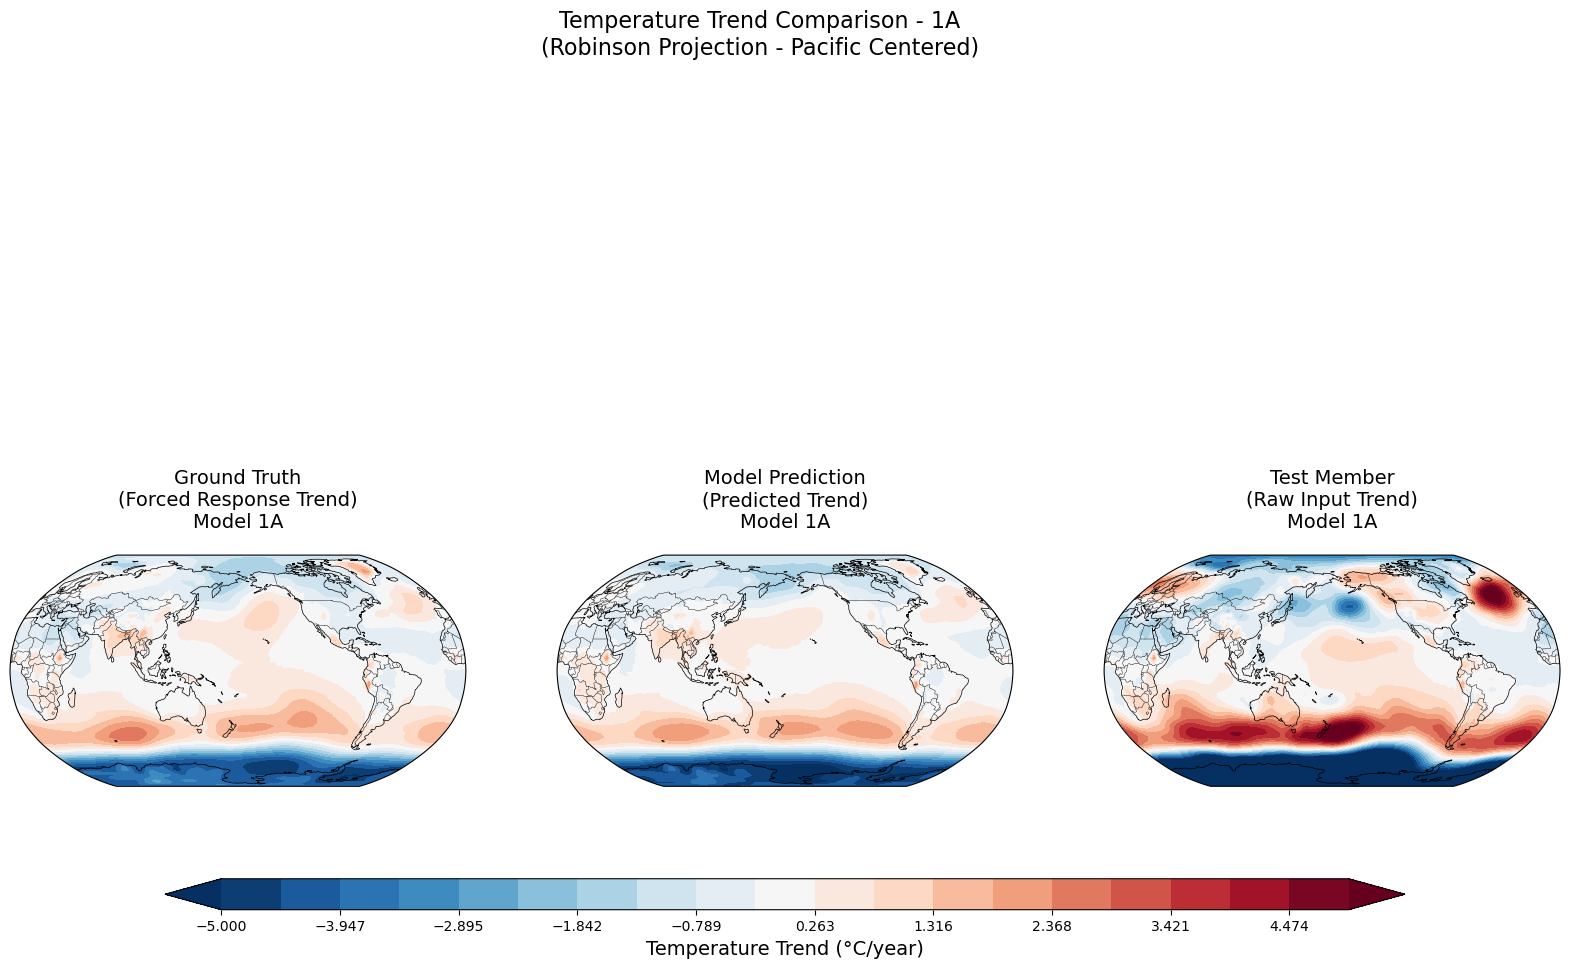

<Figure size 640x480 with 0 Axes>

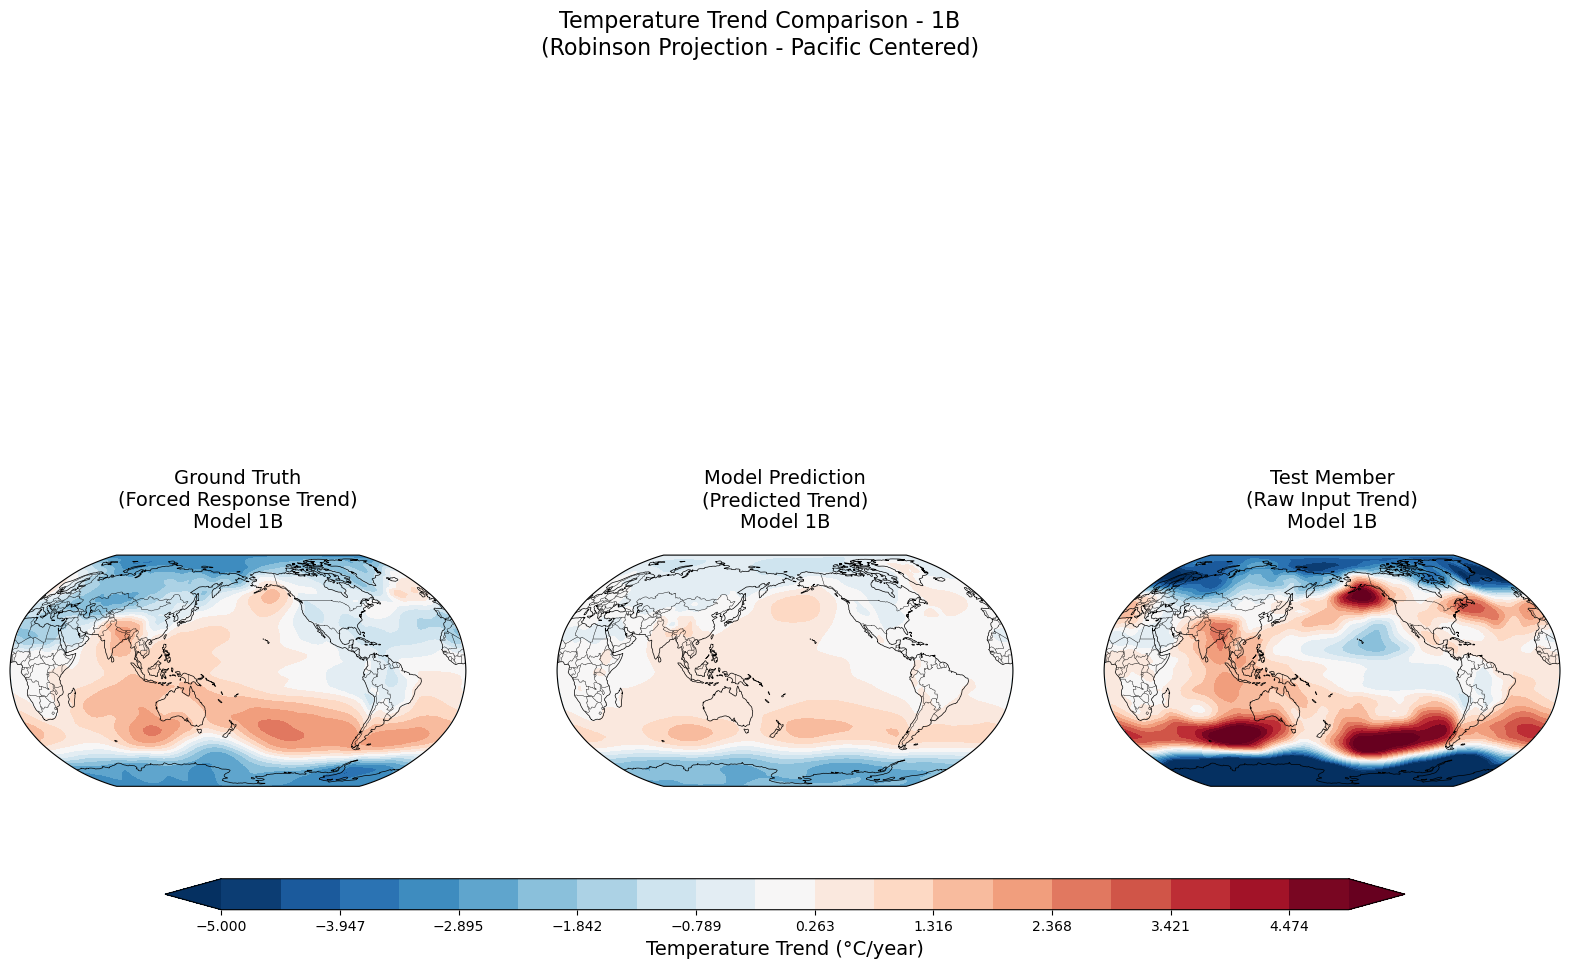

<Figure size 640x480 with 0 Axes>

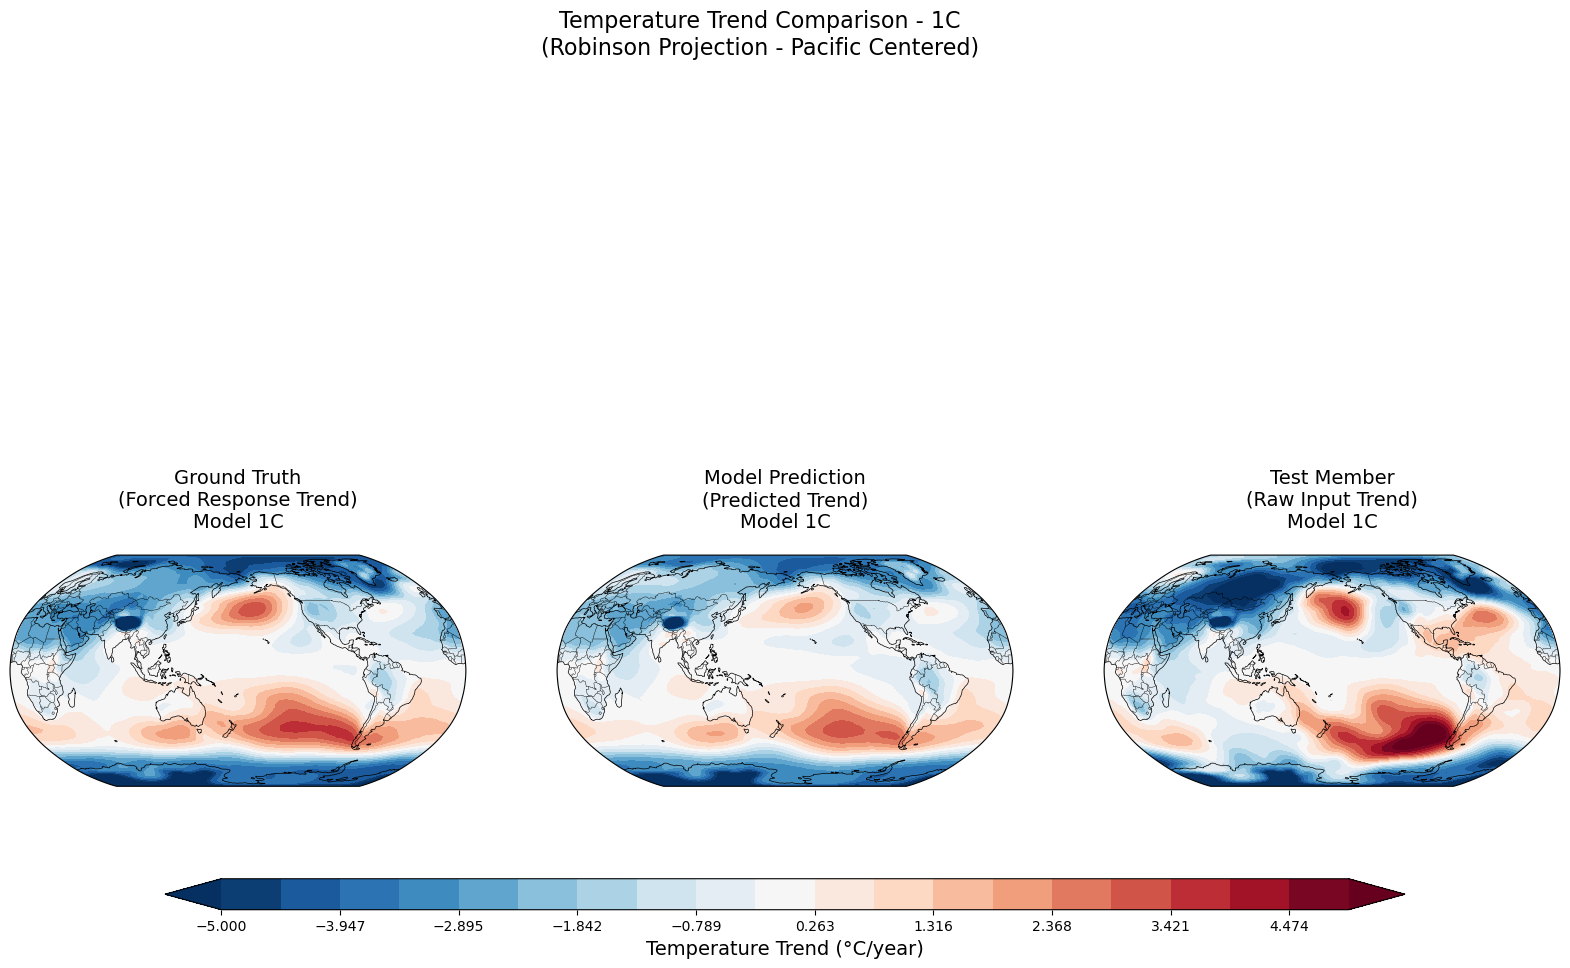

<Figure size 640x480 with 0 Axes>

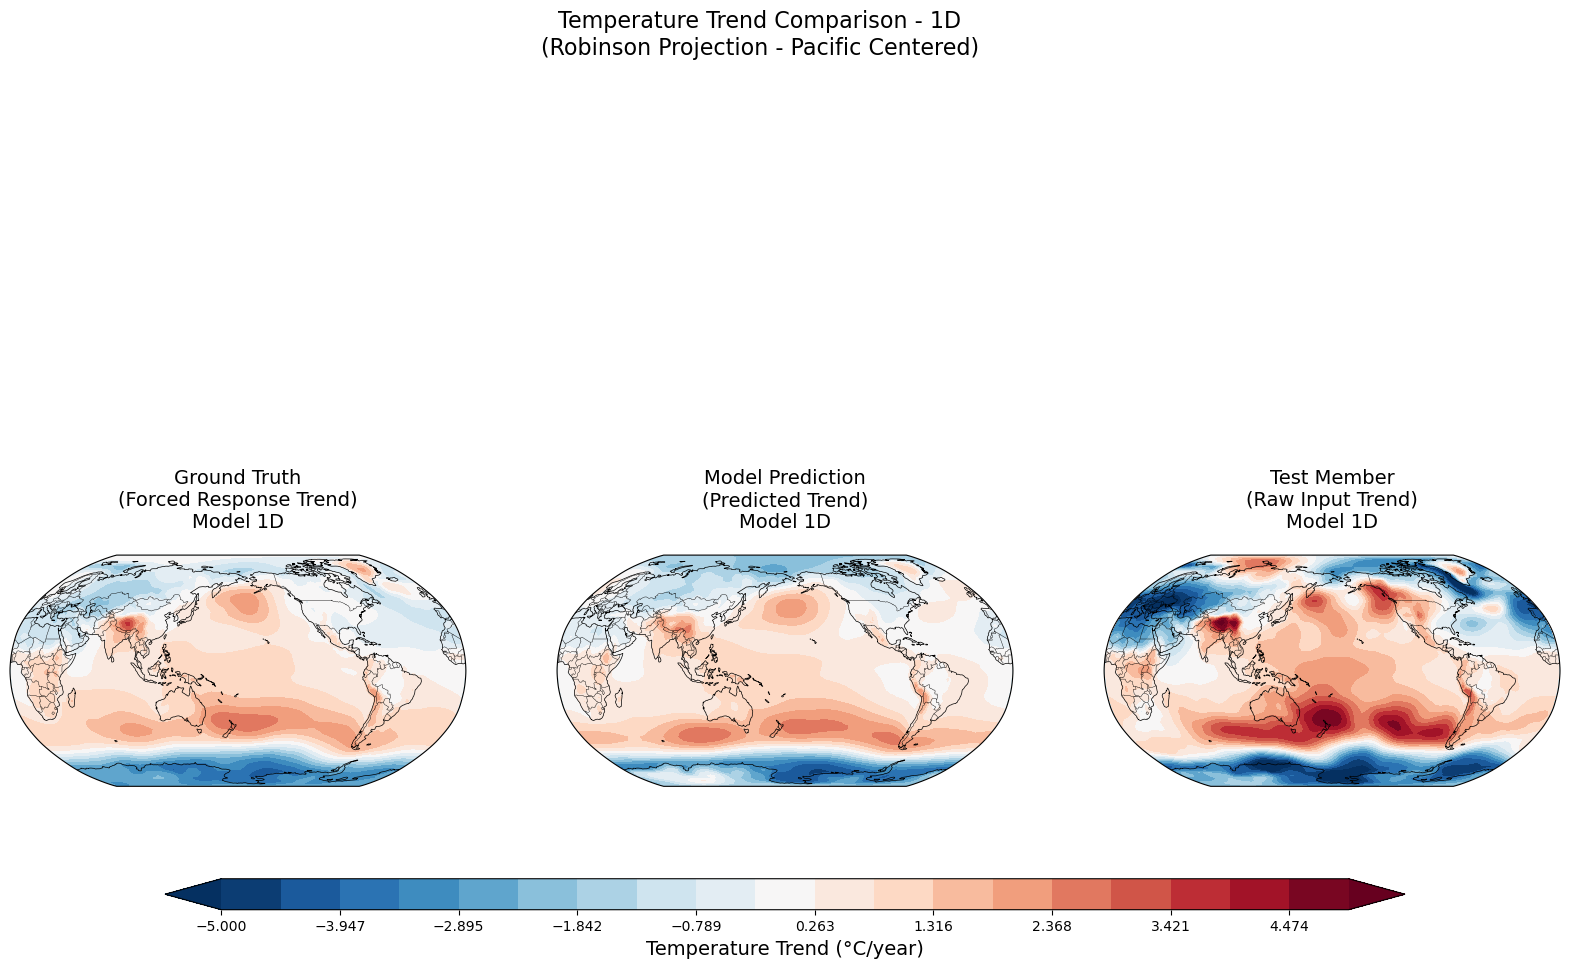

<Figure size 640x480 with 0 Axes>

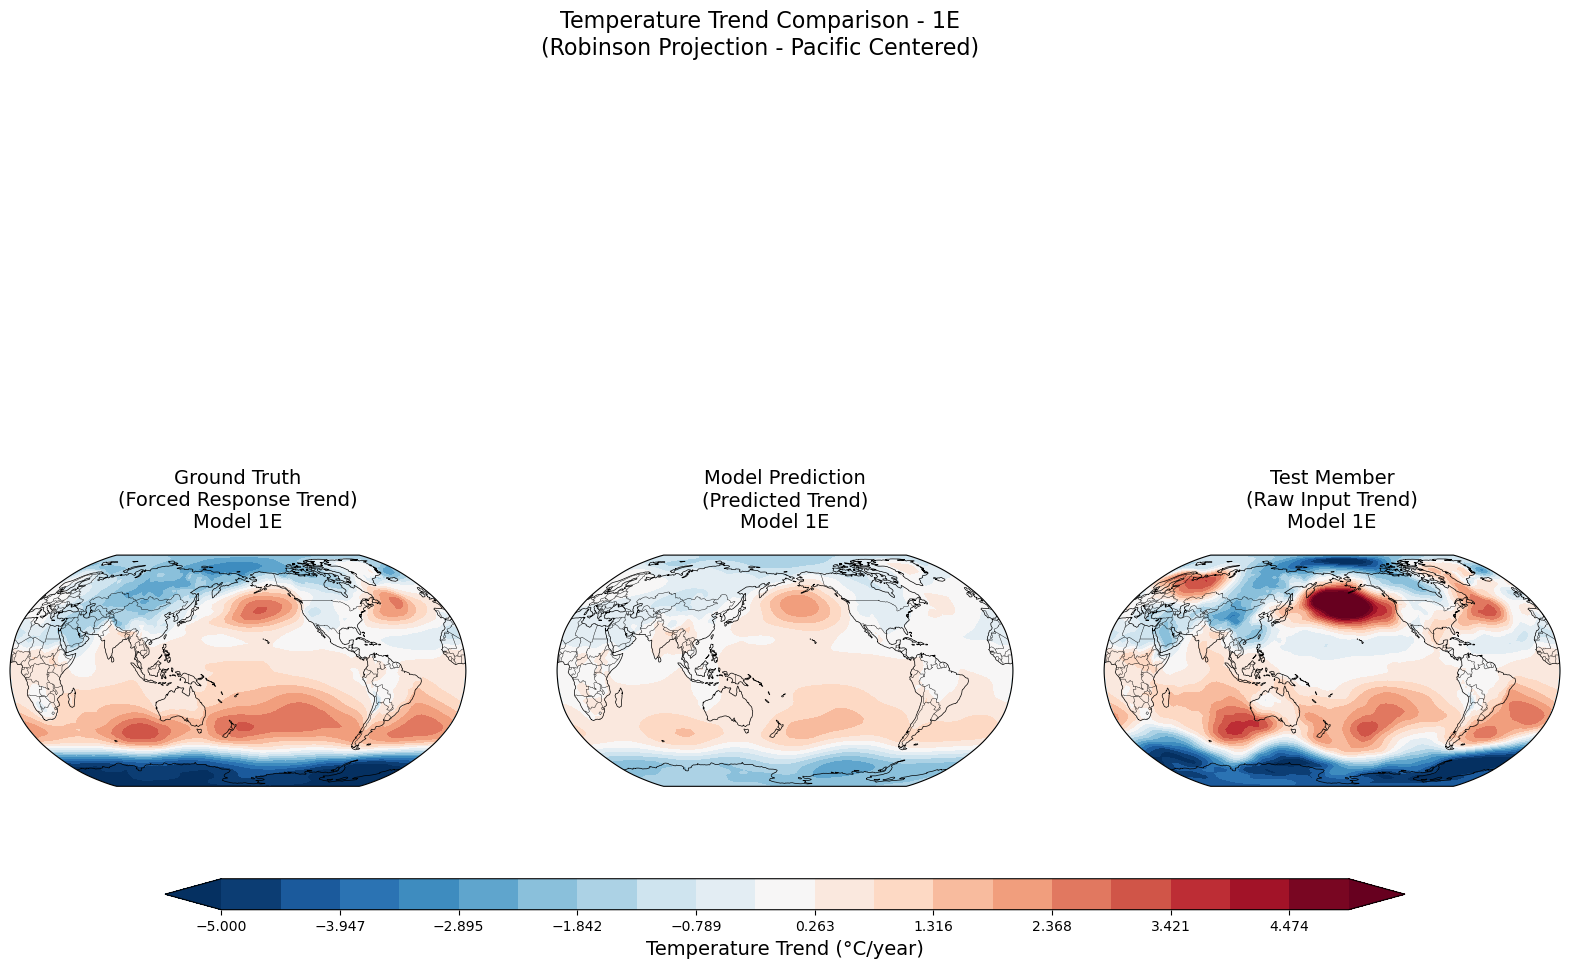

<Figure size 640x480 with 0 Axes>

In [39]:
for run_idx in range(5):
    fig3 = visualizer.plot_triple_comparison(
        trends_ground_truth_fullmap,
        trends_ridge_fullmap,
        trend_test_member,
        run_idx=run_idx,
        vmin=-5.0, vmax=5.0
    )
    plt.show()
    # plt.tight_layout()
    plt.savefig('figures/triple_comparison_{}_{}.png'.format(variable, run_idx), dpi=300)
    

## 5. Comparison with ForceSMIP Estimates

In [33]:
# Load and evaluate ForceSMIP benchmark estimates
print("Evaluating ForceSMIP benchmark estimates...")

# Compute yearly averages for estimates
estimates_yearly = np.zeros((data_estimates.shape[0], data_estimates.shape[1],
                           data_estimates.shape[2] // 12,
                           data_estimates.shape[3], data_estimates.shape[4]), dtype=np.float32)

for idx_m in range(data_estimates.shape[0]):
    estimates_yearly[idx_m] = yearly_average(data_estimates[idx_m])

# Compute trends for estimates
trends_estimates = {}
trends_estimates_fullmap = {}
for idx_m in range(estimates_yearly.shape[0]):
    trends_estimates[f'ForceSMIP_Method_{idx_m:02d}'] = compute_trends_from_data(
        estimates_yearly[idx_m].reshape(estimates_yearly[idx_m].shape[0],
                                          estimates_yearly[idx_m].shape[1],
                                          -1)[:,:,notnan_idx], trend_years
    )
    trends_estimates_fullmap[f'ForceSMIP_Method_{idx_m:02d}'] = np.zeros((trends_estimates[f'ForceSMIP_Method_{idx_m:02d}'].shape[0], x_test.shape[2]), dtype=np.float32)
    trends_estimates_fullmap[f'ForceSMIP_Method_{idx_m:02d}'][:,notnan_idx_test] = trends_estimates[f'ForceSMIP_Method_{idx_m:02d}']
    trends_estimates_fullmap[f'ForceSMIP_Method_{idx_m:02d}'][:,nan_idx_test] = np.nan  # Fill NaNs for visualization
print(f"Loaded {len(trends_estimates)} ForceSMIP benchmark methods")

Evaluating ForceSMIP benchmark estimates...


Loaded 30 ForceSMIP benchmark methods


#### Compare our methods against ForceSMIP estimates

In [34]:
# Compare our methods with ForceSMIP benchmarks
all_methods = {**predictions_dict, **trends_estimates}
full_comparison = evaluator.compare_methods(all_methods, trends_ground_truth[:,notnan_idx])

# Sort by performance
sorted_methods = sorted(full_comparison.items(), key=lambda x: x[1]['mean_nrmse'])

print("\n=== Full Method Ranking (by Mean NRMSE) ===")
print(f"{'Rank':<4} {'Method':<30} {'Mean NRMSE':<12} {'Pattern Corr':<12} {'Worst NRMSE':<12}")
print("-" * 75)

for rank, (method, results) in enumerate(sorted_methods, 1):
    print(f"{rank:<4} {method:<30} {results['mean_nrmse']:<12.4f} {results['mean_pattern_corr']:<12.4f} {results['worst_nrmse']:<12.4f}")

# Highlight our methods
our_methods = ['Ridge', 'Ridge + Low-rank', 'Ridge + Smoothing', 'Ridge + Low-rank + Smoothing']
print("\n=== Our Methods Performance ===")
for method in our_methods:
    rank = next(i for i, (m, _) in enumerate(sorted_methods, 1) if m == method)
    print(f"{method}: Rank {rank}/{len(sorted_methods)}")


=== Full Method Ranking (by Mean NRMSE) ===
Rank Method                         Mean NRMSE   Pattern Corr Worst NRMSE 
---------------------------------------------------------------------------
1    Ridge                          0.4848       0.9084       0.7919      
2    Ridge + Low-rank               0.4921       0.9071       0.7769      
3    Ridge + Smoothing              0.4969       0.9036       0.8126      
4    Ridge + Low-rank + Smoothing   0.5042       0.9018       0.7986      
5    ForceSMIP_Method_28            0.5701       0.8838       0.9547      
6    ForceSMIP_Method_14            0.5751       0.8488       0.7381      
7    ForceSMIP_Method_09            0.5936       0.8317       0.9629      
8    ForceSMIP_Method_03            0.6161       0.8455       0.8443      
9    ForceSMIP_Method_01            0.6168       0.8143       0.9282      
10   ForceSMIP_Method_23            0.6227       0.8649       0.9995      
11   ForceSMIP_Method_08            0.6444       0.821

## 7. Interpretation: display grid cell contributions in W matrix

#### Display the rows of W as grid maps (black cross is the grid celll of interest)

Using vmin=-0.005, vmax=0.005 for colorbar
Feature index 500 corresponds to lat index 3, lon index 68
Feature coordinates: Latitude -81.25, Longitude 171.25
Using vmin=-0.005, vmax=0.005 for colorbar
Feature index 1000 corresponds to lat index 6, lon index 136
Feature coordinates: Latitude -73.75, Longitude 341.25
Using vmin=-0.005, vmax=0.005 for colorbar
Feature index 1500 corresponds to lat index 10, lon index 60
Feature coordinates: Latitude -63.75, Longitude 151.25
Using vmin=-0.005, vmax=0.005 for colorbar
Feature index 2000 corresponds to lat index 13, lon index 128
Feature coordinates: Latitude -56.25, Longitude 321.25
Using vmin=-0.005, vmax=0.005 for colorbar
Feature index 5000 corresponds to lat index 34, lon index 104
Feature coordinates: Latitude -3.75, Longitude 261.25
Using vmin=-0.005, vmax=0.005 for colorbar
Feature index 7500 corresponds to lat index 52, lon index 12
Feature coordinates: Latitude 41.25, Longitude 31.25
Using vmin=-0.005, vmax=0.005 for colorbar
Featur

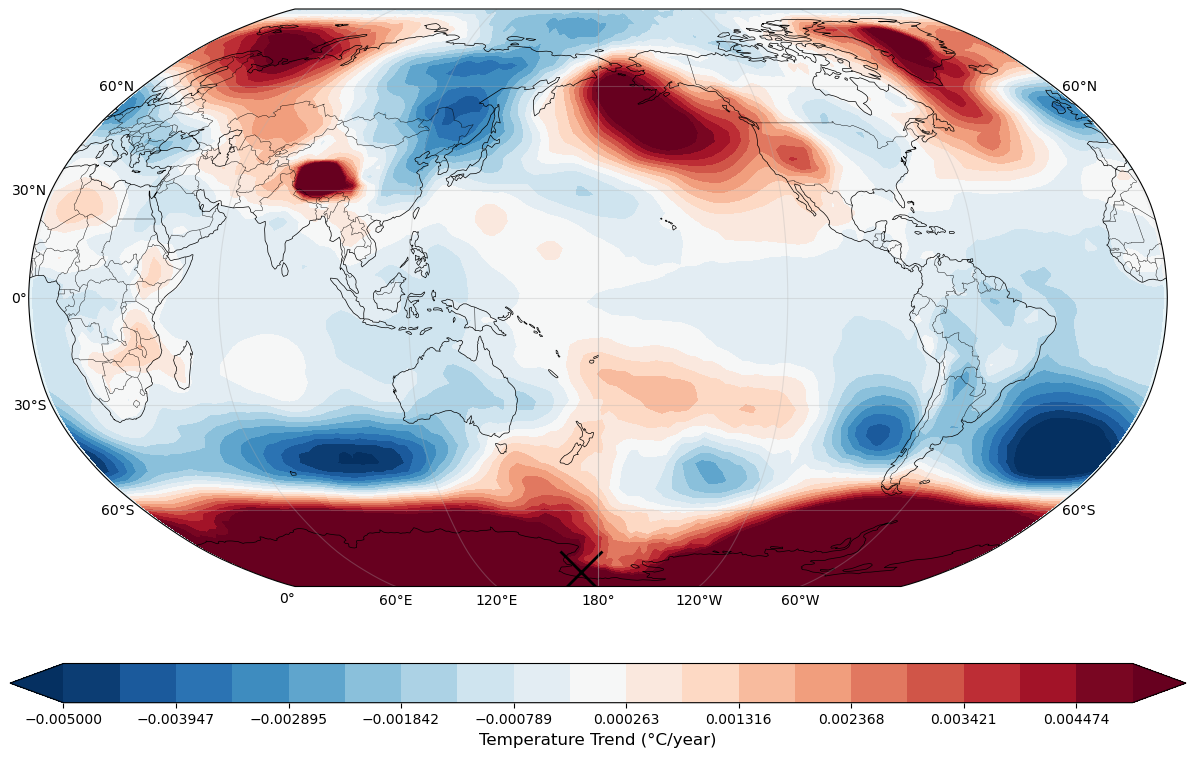

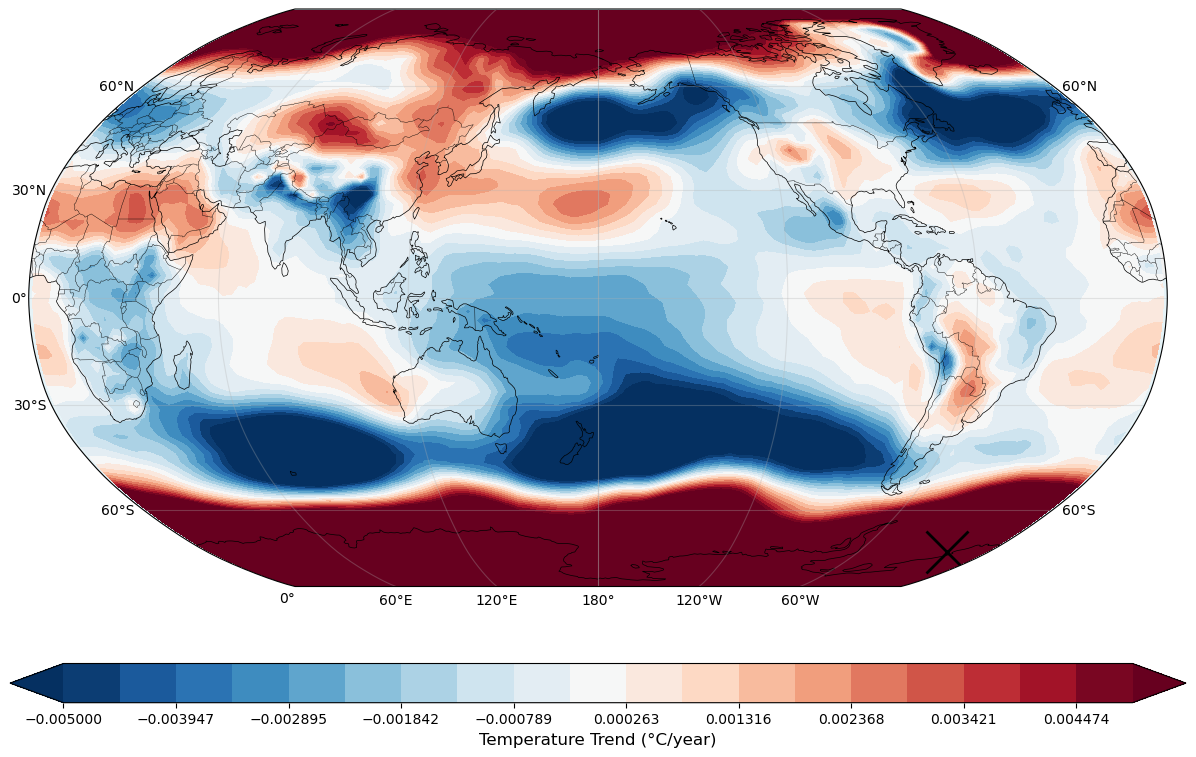

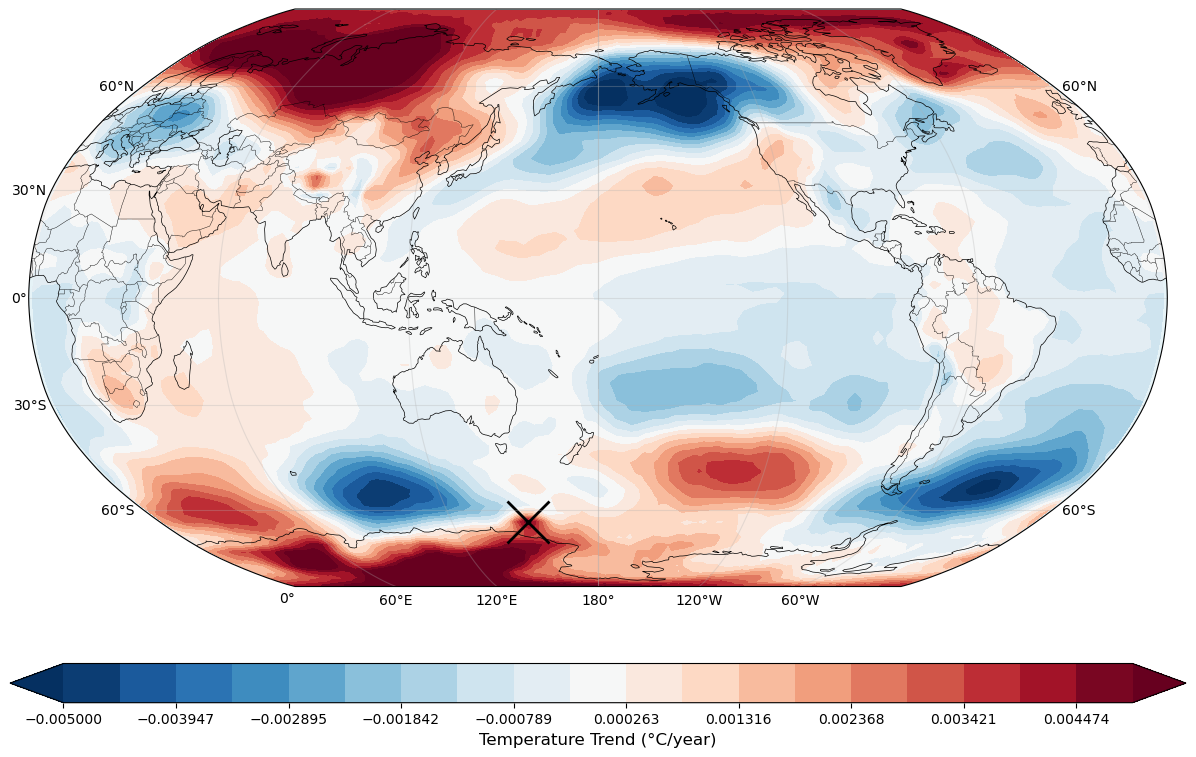

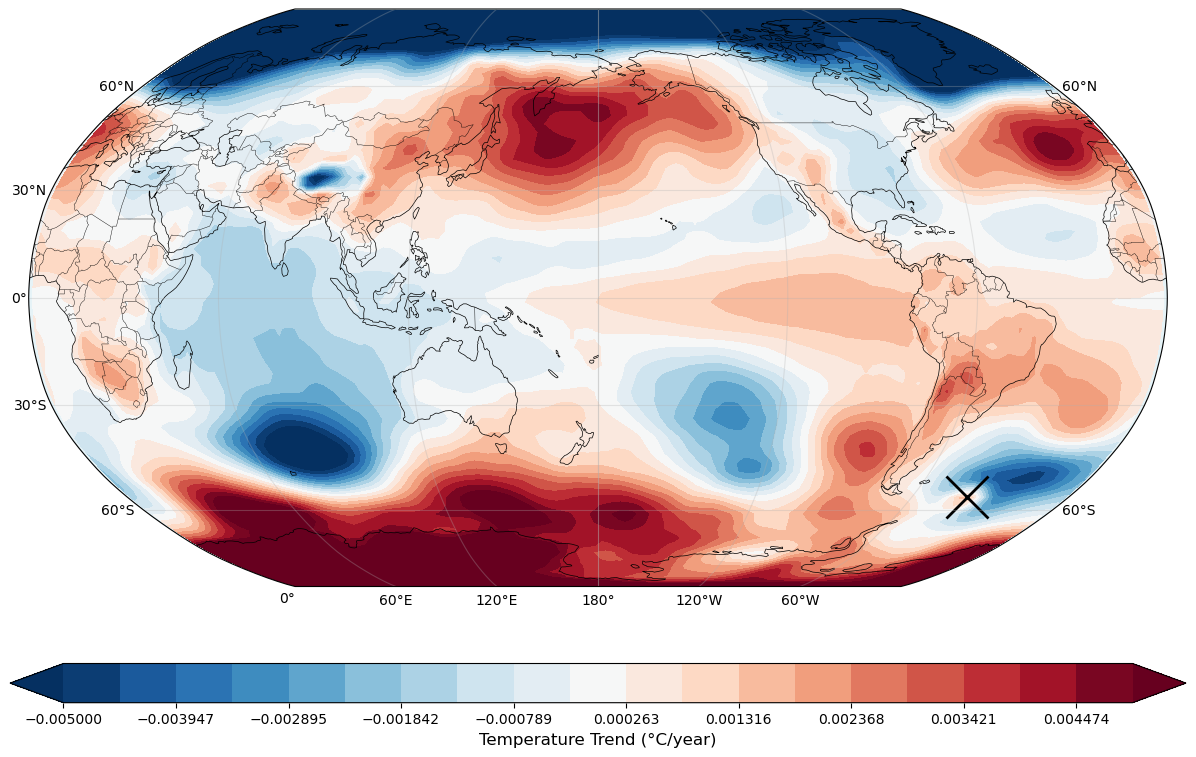

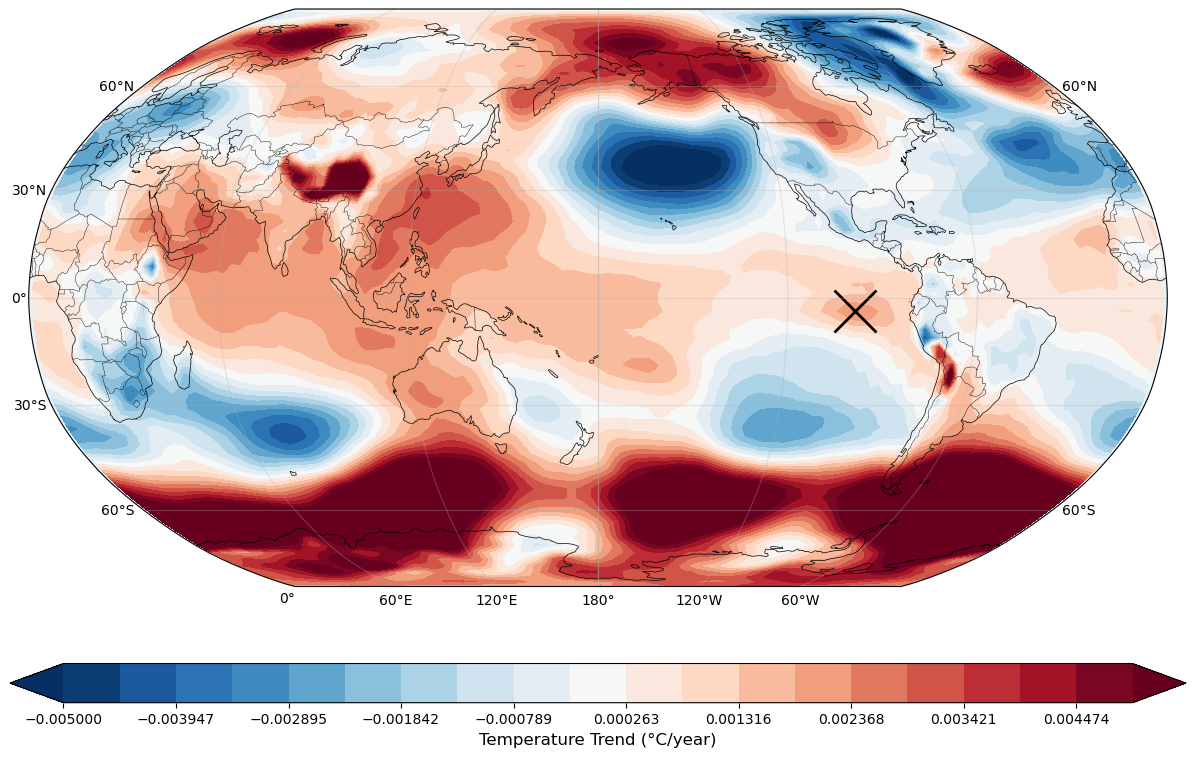

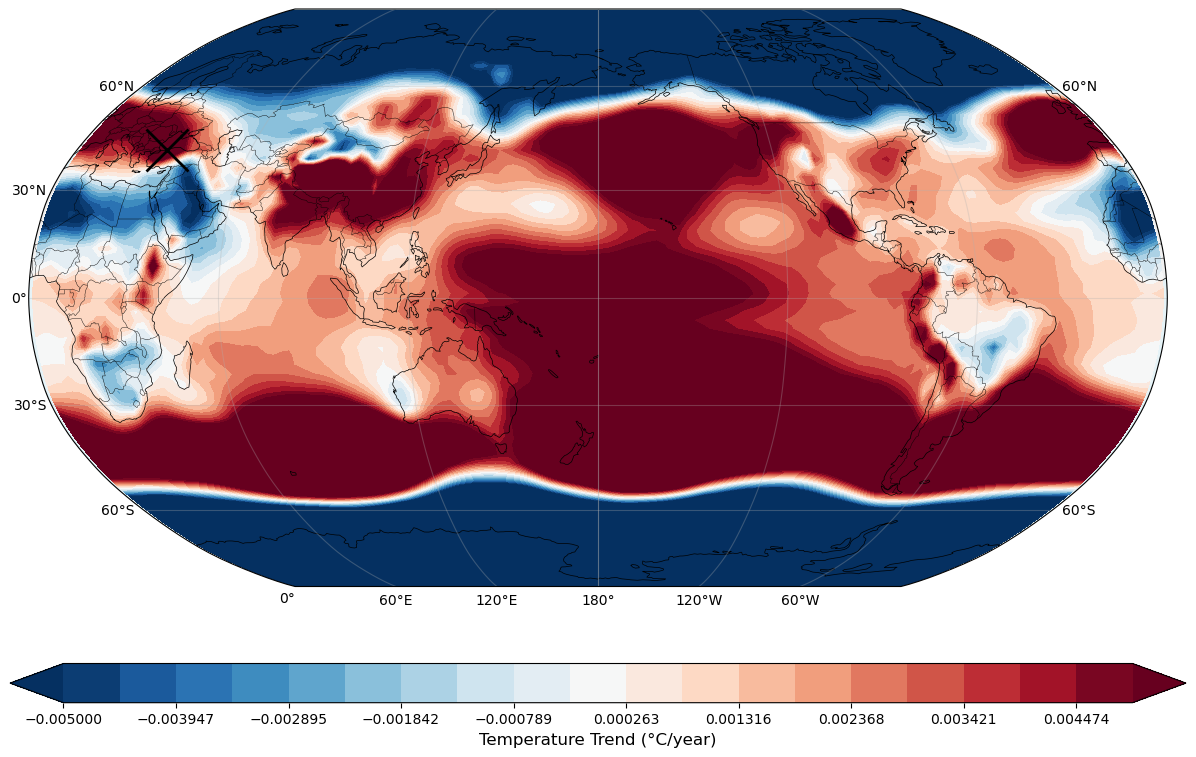

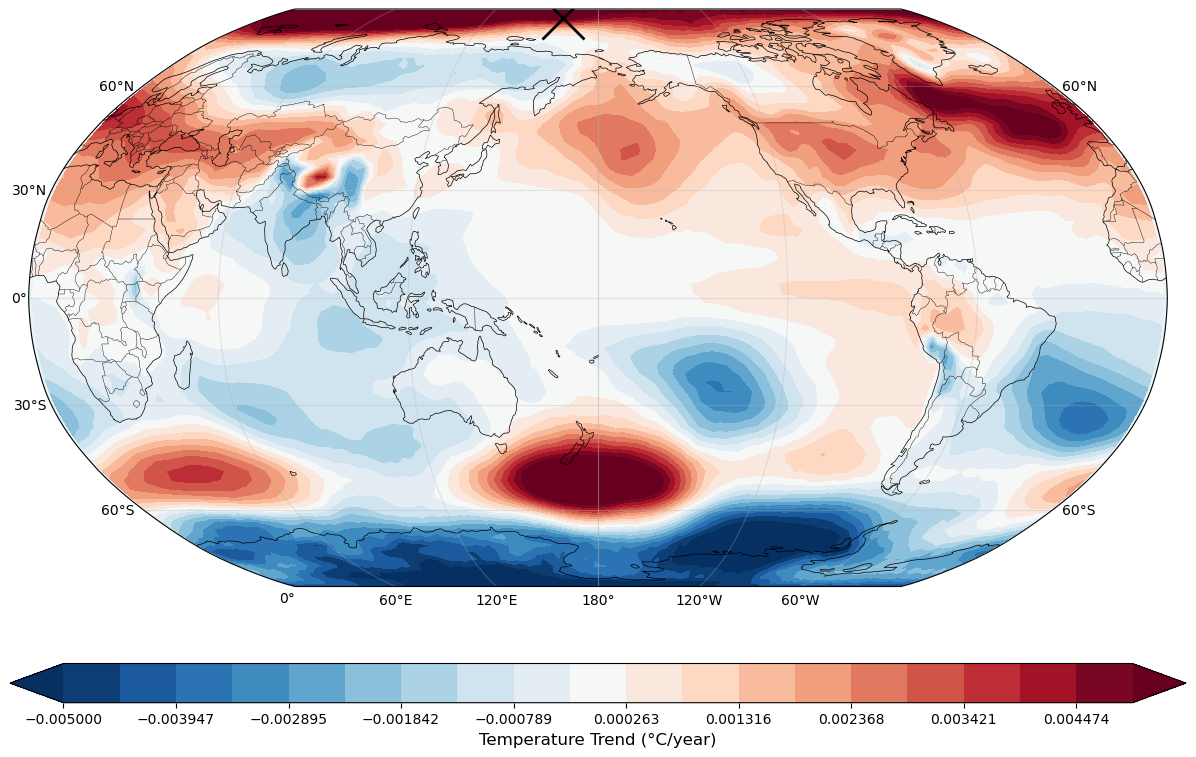

In [35]:
# display some rows of w_ridge_fullmap and higlight the gridcell of interest (idx_feat)
# reshape the trends for visualization
w_ridge_fullmap = np.zeros((w_ridge.shape[0], x_test.shape[2]), dtype=np.float32)
w_ridge_fullmap[:,notnan_idx] = w_ridge 
w_ridge_fullmap[:,nan_idx] = np.nan  # Fill NaNs for visualization


for feat_idx in [500, 1000, 1500, 2000, 5000, 7500, 10000]:
    fig = visualizer.plot_robinson_projection_weight_matrix(w_ridge_fullmap, 
                                title= "Global Temperature Trend",
                                cmap= 'RdBu_r', 
                                feat_idx = feat_idx, 
                                vmin=-0.005, vmax=0.005,
                                central_longitude = 180)

In [36]:
import pandas as pd
import os

# Prepare results for CSV
csv_rows = []
for rank, (method, results) in enumerate(sorted_methods, 1):
    csv_rows.append({
        "Rank": rank,
        "Method": method,
        "Mean_NRMSE": results['mean_nrmse'],
        "Pattern_Corr": results['mean_pattern_corr'],
        "Worst_NRMSE": results['worst_nrmse']
    })

df_results = pd.DataFrame(csv_rows)
os.makedirs("results", exist_ok=True)
df_results.to_csv("results/trend_rmse_results.csv", index=False)
print("Trend RMSE results exported to results/trend_rmse_results.csv")

Trend RMSE results exported to results/trend_rmse_results.csv


## 7. Parameter Sensitivity Analysis (cross-validation)

In [37]:
## 6.5 Cross-Validation Lambda Optimization

print("="*70)
print("         CROSS-VALIDATION LAMBDA OPTIMIZATION")
print("="*70)

# Import the cross-validation function
from algorithms import cross_validation_lambda_optimization, cross_validation_lambda_rank_optimization,\
                        plot_cv_lambda_results, plot_cv_lambda_rank_results

# Define lambda values to test (broader range for better optimization)
# lambda_values_cv = [100.0, 500.0, 1000.0, 2500.0, 5000.0, 7500.0, 10000.0]
# rank_values_cv = [5, 10, 15, 20, 25, 30, 50, 100]

lambda_values_cv = [10.0, 50.0, 100.0, 500.0, 1000.0, 5000.0, 10000.0,50000.0,100000.0,500000.0]

print("Performing cross-validation to optimize lambda for worst-case performance...")

# Optimize lambda using cross-validation with worst-case objective


cv_optimization = cross_validation_lambda_optimization(
    x_train_dict_filtered, y_train_dict_filtered,
    lambda_values=lambda_values_cv,
    cv_folds=5,
    objective='worst_case',  # Optimize for worst-case NRMSE
    verbose=True
)


# Plot cross-validation results
fig_cv = plot_cv_lambda_results(cv_optimization, figsize=(18, 5))
plt.show()


# Extract optimal lambda
optimal_lambda_cv = cv_optimization['best_lambda']
print(f"\n🎯 OPTIMAL LAMBDA (CV-optimized): {optimal_lambda_cv}")
print(f"   Worst-case NRMSE: {cv_optimization['cv_results'][optimal_lambda_cv]['worst_nrmse']:.4f}")
print(f"   Mean NRMSE: {cv_optimization['cv_results'][optimal_lambda_cv]['mean_nrmse']:.4f}")

         CROSS-VALIDATION LAMBDA OPTIMIZATION
Performing cross-validation to optimize lambda for worst-case performance...
Cross-validation with 5 folds for 10 lambda values...
Optimization objective: worst_case
  Testing λ = 10.0


    Mean NRMSE: 3.7716
   Q75 NRMSE: 2.0662
   Q90 NRMSE: 8.3539
   Q95 NRMSE: 10.4499
    Worst NRMSE: 12.5458
    NRMSE Variance: 19.4144
  Testing λ = 50.0
    Mean NRMSE: 7.9516
   Q75 NRMSE: 1.8334
   Q90 NRMSE: 21.4232
   Q95 NRMSE: 27.9531
    Worst NRMSE: 34.4830
    NRMSE Variance: 176.1500
  Testing λ = 100.0


KeyboardInterrupt: 

In [ ]:
## 6.5 Cross-Validation (Lambda, rank) Optimization

print("="*70)
print("         CROSS-VALIDATION (LAMBDA, RANK) OPTIMIZATION")
print("="*70)


# Define lambda values to test (broader range for better optimization)
lambda_values_cv = [10.0, 50.0, 100.0, 500.0, 1000.0, 5000.0, 10000.0,50000.0,100000.0,500000.0]
rank_values_cv = [5, 10, 15, 20, 25, 30, 50, 100]

# lambda_values_cv = [100.0, 500.0,1000.0]
# rank_values_cv = [2,5, 10]

print("Performing cross-validation to optimize lambda for worst-case performance...")

# Optimize lambda using cross-validation with worst-case objective

cv_optimization = cross_validation_lambda_rank_optimization(
    x_train_dict_filtered, y_train_dict_filtered,
    lambda_values=lambda_values_cv,
    rank_values=rank_values_cv,
    cv_folds=5,
    objective='worst_case',  # Optimize for worst-case NRMSE
    verbose=True
)

fig_tmp = plot_cv_lambda_rank_results(cv_optimization)
plt.show()

# Extract optimal lambda
optimal_lambda_cv = cv_optimization['best_lambda']
optimal_rank_cv = cv_optimization['best_rank']
print(f"\n🎯 OPTIMAL LAMBDA (CV-optimized): {optimal_lambda_cv}")
print(f"🎯 OPTIMAL RANK (CV-optimized): {optimal_rank_cv}")
print(f"   Worst-case NRMSE: {cv_optimization['cv_results'][(optimal_lambda_cv,optimal_rank_cv)]['worst_nrmse']:.4f}")
print(f"   Mean NRMSE: {cv_optimization['cv_results'][(optimal_lambda_cv,optimal_rank_cv)]['mean_nrmse']:.4f}")

         CROSS-VALIDATION (LAMBDA, RANK) OPTIMIZATION
Performing cross-validation to optimize lambda for worst-case performance...
Cross-validation with 5 folds for 10 lambda values...
Optimization objective: worst_case
  Testing λ = 10.0

Setting up low-rank solver...
Computing SVD for low-rank approximations...
Solving ridge regression with λ=10.0
Input shape: X=torch.Size([29835, 10368]), Y=torch.Size([29835, 10368])
Reshaped: X=torch.Size([29835, 10368]), Y=torch.Size([29835, 10368])
Ridge weights computed: torch.Size([10368, 10368])


SVD computed: U=torch.Size([40203, 10368]), S=torch.Size([10368]), Vt=torch.Size([10368, 10368])
Singular values range: 0.000015 to 6860.553223
Computed solutions for ranks: [5, 10, 15, 20, 25, 30, 50, 100]


KeyboardInterrupt: 

In [ ]:
optimal_lambda_cv = cv_optimization['best_lambda']
# optimal_rank_cv = cv_optimization['best_rank']
print(f"\n🎯 OPTIMAL LAMBDA (CV-optimized): {optimal_lambda_cv}")
print(f"🎯 OPTIMAL RANK (CV-optimized): {optimal_rank_cv}")
print(f"   Worst-case NRMSE: {cv_optimization['cv_results'][(optimal_lambda_cv,optimal_rank_cv)]['worst_nrmse']:.4f}")
print(f"   Mean NRMSE: {cv_optimization['cv_results'][(optimal_lambda_cv,optimal_rank_cv)]['mean_nrmse']:.4f}")


🎯 OPTIMAL LAMBDA (CV-optimized): 50.0
🎯 OPTIMAL RANK (CV-optimized): 100
   Worst-case NRMSE: 0.6801
   Mean NRMSE: 0.6446


In [ ]:
# re run the model with optimized lambda and rank
# Train global ridge regression model
lambda_reg_opt = optimal_lambda_cv
primary_rank_opt = optimal_rank_cv


# print(f"Training ridge regression with lambda={lambda_reg}...")
w_ridge = ridge_regression(x_train_merged_filtered,y_train_merged_filtered, lambda_reg_opt, surface=None, verbose=True)

print(f"Ridge weights shape: {w_ridge.shape}")
# Setup low-rank solver for efficient multiple rank solutions
print(f"\nSetting up low-rank solver...")
lr_solver = LowRankSolver()
lr_solver.W_full = w_ridge
lr_solver.fit(x_train_merged_filtered, y_train_merged_filtered, lambda_reg_opt, surface=None, verbose=True)

# Get solutions for multiple ranks efficiently
ranks_to_test = [primary_rank_opt]
rank_solutions = lr_solver.get_multiple_ranks(ranks_to_test, verbose=True)  

# Use the primary rank solution
w_ridge_lr = rank_solutions[primary_rank_opt]
print(f"Primary rank-{primary_rank_opt} weights shape: {w_ridge_lr.shape}")

# Make predictions using different methods
print("Making predictions...")
# Global models
y_pred_ridge = x_test_filtered @ w_ridge
y_pred_ridge_lr = x_test_filtered @ w_ridge_lr

y_pred_ridge_smooth = x_test_smooth @ w_ridge
y_pred_ridge_lr_smooth = x_test_smooth @ w_ridge_lr

# Initialize evaluator
evaluator = ForceSMIPEvaluator()
# Convert predictions to yearly averages and compute trends
def to_yearly_and_trends(pred_data, trend_years=slice(30, None)):
    """Helper function to convert monthly to yearly and compute trends."""
    pred_numpy = pred_data.cpu().numpy() if isinstance(pred_data, torch.Tensor) else pred_data
    pred_yearly = pred_numpy.reshape(pred_numpy.shape[0], pred_numpy.shape[1] // 12, 12, pred_numpy.shape[2])
    pred_yearly = np.nanmean(pred_yearly, axis=2)
    return compute_trends_from_data(pred_yearly, trend_years)

# Compute trends for all predictions
trend_years = slice(30, None)  # Last 43 years for trend computation
# reshape the data ground truth for trend computation
data_ground_truth_yearly = data_ground_truth_yearly.reshape(
    data_ground_truth_yearly.shape[0], 
    data_ground_truth_yearly.shape[1],
    -1
)  
trends_ground_truth = compute_trends_from_data(data_ground_truth_yearly, trend_years)
trends_ridge = to_yearly_and_trends(y_pred_ridge, trend_years)
trends_ridge_smooth = to_yearly_and_trends(y_pred_ridge_smooth , trend_years)
trends_ridge_lr = to_yearly_and_trends(y_pred_ridge_lr, trend_years)
trends_ridge_lr_smooth = to_yearly_and_trends(y_pred_ridge_lr_smooth, trend_years)

print(f"Trends computed for {trends_ground_truth.shape[0]} test cases")
print(f"Trend groundtruth shape: {trends_ground_truth.shape}")
print(f"Trend shape: {trends_ridge.shape}")

# Evaluate all methods
predictions_dict = {
    'Ridge': trends_ridge,
    'Ridge + Smoothing': trends_ridge_smooth,
    'Ridge + Low-rank': trends_ridge_lr,
    'Ridge + Low-rank + Smoothing': trends_ridge_lr_smooth
}

# comparison_results = evaluator.compare_methods(predictions_dict, trends_ground_truth[:, notnan_idx])

# Compare our methods with ForceSMIP benchmarks
all_methods = {**predictions_dict, **trends_estimates}
full_comparison = evaluator.compare_methods(all_methods, trends_ground_truth[:,notnan_idx])

# Sort by performance
sorted_methods = sorted(full_comparison.items(), key=lambda x: x[1]['mean_nrmse'])

print("\n=== Full Method Ranking (by Mean NRMSE) ===")
print(f"{'Rank':<4} {'Method':<30} {'Mean NRMSE':<12} {'Pattern Corr':<12} {'Worst NRMSE':<12}")
print("-" * 75)

for rank, (method, results) in enumerate(sorted_methods, 1):
    print(f"{rank:<4} {method:<30} {results['mean_nrmse']:<12.4f} {results['mean_pattern_corr']:<12.4f} {results['worst_nrmse']:<12.4f}")

# Highlight our methods
our_methods = ['Ridge', 'Ridge + Low-rank', 'Ridge + Smoothing', 'Ridge + Low-rank + Smoothing']
print("\n=== Our Methods Performance ===")
for method in our_methods:
    rank = next(i for i, (m, _) in enumerate(sorted_methods, 1) if m == method)
    print(f"{method}: Rank {rank}/{len(sorted_methods)}")


Solving ridge regression with λ=50.0
Input shape: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])
Reshaped: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])
Ridge weights computed: torch.Size([10368, 10368])
Ridge weights shape: torch.Size([10368, 10368])

Setting up low-rank solver...
Computing SVD for low-rank approximations...
SVD computed: U=torch.Size([51253, 10368]), S=torch.Size([10368]), Vt=torch.Size([10368, 10368])
Singular values range: 0.000000 to 645.742798
Computed solutions for ranks: [100]
Primary rank-100 weights shape: torch.Size([10368, 10368])
Making predictions...
Trends computed for 8 test cases
Trend groundtruth shape: (8, 10368)
Trend shape: (8, 10368)

=== Full Method Ranking (by Mean NRMSE) ===
Rank Method                         Mean NRMSE   Pattern Corr Worst NRMSE 
---------------------------------------------------------------------------
1    Ridge + Smoothing              0.6779       0.7577       0.9565      
2    Ridge             

## 8. Summary and Conclusions

In [ ]:
print("\n" + "="*60)
print("                 ANALYSIS SUMMARY")
print("="*60)

print(f"\nDataset: {variable.upper()} (Surface Air Temperature)")
print(f"Training models: {len(dic_data)}")
print(f"Test models: {len(test_models)}")
print(f"Grid resolution: {latitude.shape[0]} x {longitude.shape[0]}")
print(f"Trend period: Years {trend_years.start or 0} to {trend_years.stop or 'end'}")

print("\nBest performing method (our implementation):")
best_our_method = min(predictions_dict.keys(), 
                     key=lambda x: comparison_results[x]['mean_nrmse'])
best_results = comparison_results[best_our_method]
print(f"  Method: {best_our_method}")
print(f"  Mean NRMSE: {best_results['mean_nrmse']:.4f}")
print(f"  Mean Pattern Correlation: {best_results['mean_pattern_corr']:.4f}")
print(f"  Worst Case NRMSE: {best_results['worst_nrmse']:.4f}")

# Overall ranking
our_rank = next(i for i, (m, _) in enumerate(sorted_methods, 1) if m == best_our_method)
print(f"\nOverall ranking: {our_rank}/{len(sorted_methods)} among all methods")

if our_rank <= len(sorted_methods) // 4:
    print("🏆 Excellent performance - Top quartile!")
elif our_rank <= len(sorted_methods) // 2:
    print("✅ Good performance - Above median")
else:
    print("⚠️ Room for improvement")

print("\nKey findings:")
print("- Ridge regression with proper regularization is effective")
print("- Low-rank approximation can improve generalization")
print("- Weighted ensemble methods show promise")
print("- Temporal smoothing effects depend on the specific case")

print("\n" + "="*60)



                 ANALYSIS SUMMARY

Dataset: PR (Surface Air Temperature)
Training models: 5
Test models: 8
Grid resolution: 72 x 144
Trend period: Years 30 to end

Best performing method (our implementation):
  Method: Ridge + Smoothing
  Mean NRMSE: 0.6872
  Mean Pattern Correlation: 0.7502
  Worst Case NRMSE: 0.9597

Overall ranking: 1/34 among all methods
🏆 Excellent performance - Top quartile!

Key findings:
- Ridge regression with proper regularization is effective
- Low-rank approximation can improve generalization
- Weighted ensemble methods show promise
- Temporal smoothing effects depend on the specific case

